In [1]:
import pandas as pd
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore

import numpy as np

Data Loading

In [2]:
df = pd.read_csv('C:\Credit_Risk\credit_risk_dataset.csv')

In [3]:
%pip install xgboost==2.1.4

Note: you may need to restart the kernel to use updated packages.


EDA|

In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.shape

(32581, 12)

In [6]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Checking for class imbalance 

In [7]:
df['loan_status'].unique()
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

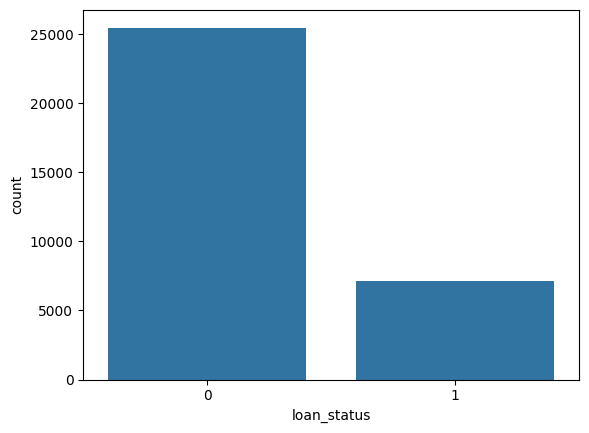

In [8]:
sns.countplot(data=df,x='loan_status')

Outliers Check

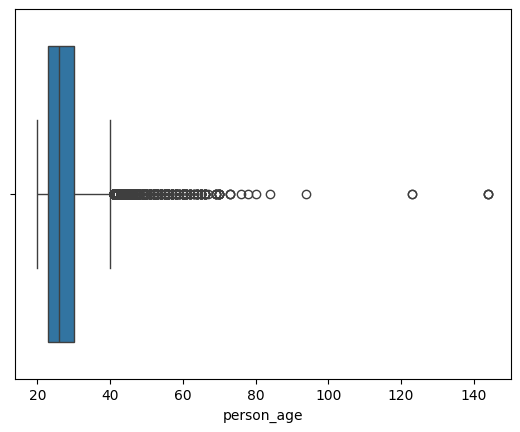

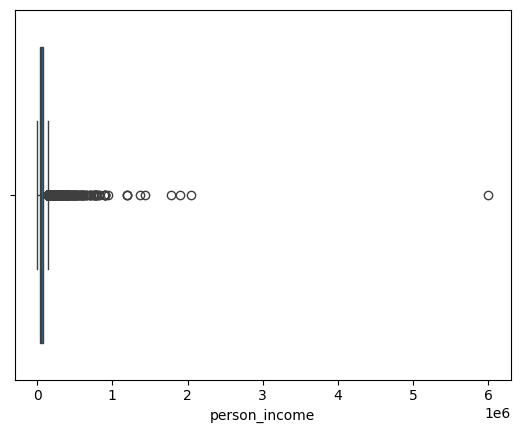

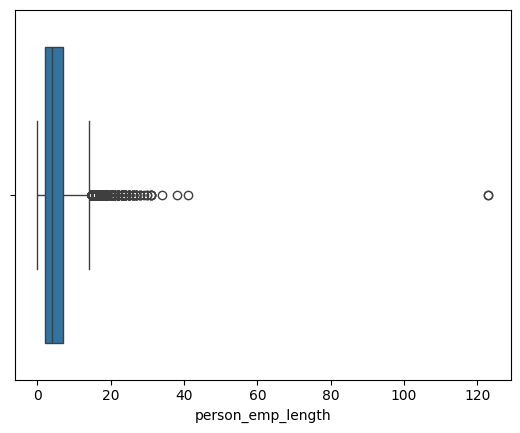

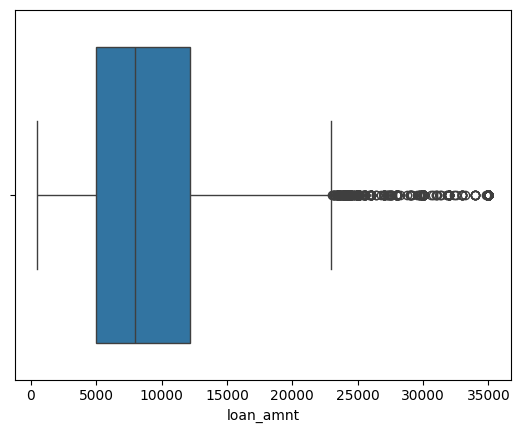

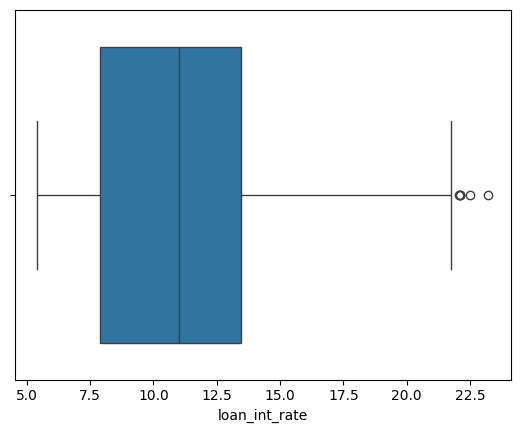

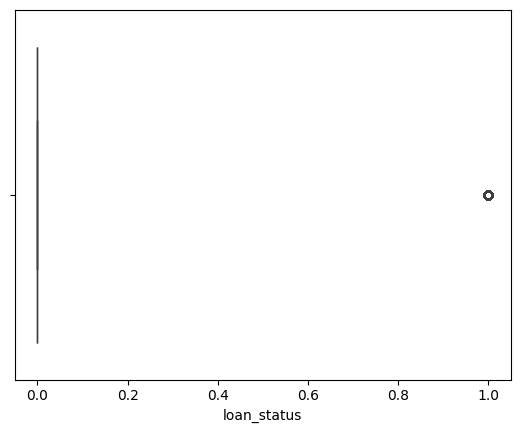

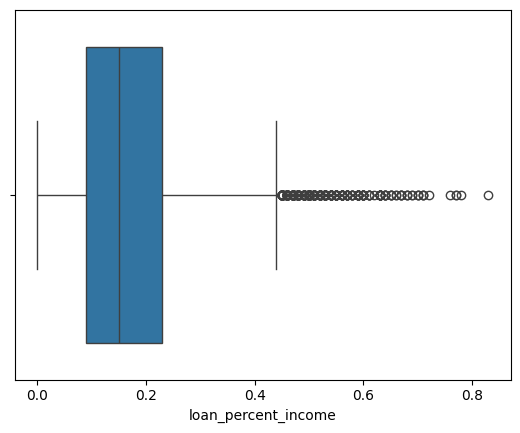

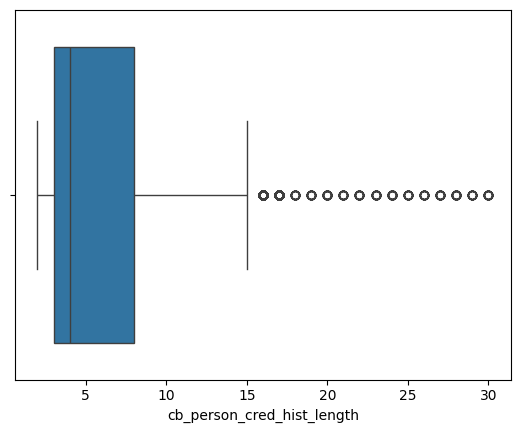

In [9]:
num_cols = df.select_dtypes(include=np.number).columns

for i in num_cols:
    sns.boxplot(x=df[i])
    plt.show()

In [10]:
(df['person_age'] > 100).sum()

np.int64(5)

In [11]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Correlation Check

<Axes: >

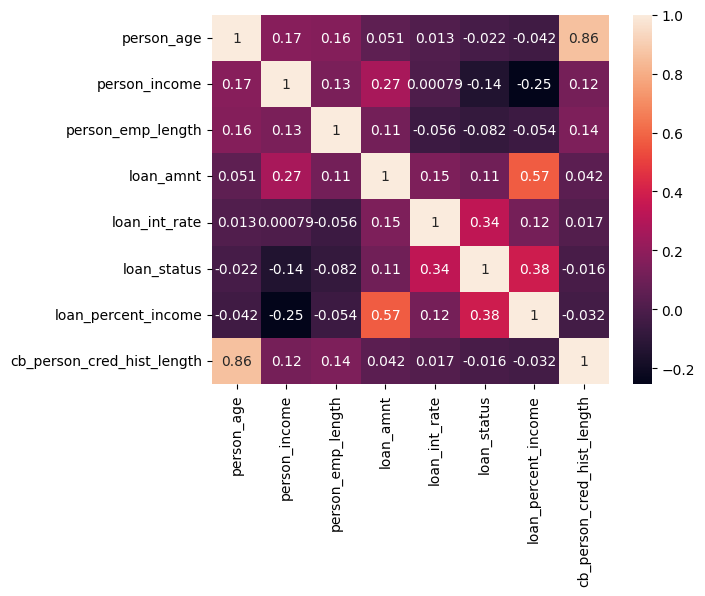

In [12]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

Data Cleaning and Outlier handling

In [13]:
df_copy = df.copy()

df_copy.drop_duplicates(inplace=True)

df_copy = df_copy[df_copy['person_age']>=18]

df_copy = df_copy[df_copy['person_age']<=100]

In [14]:
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

df_copy = df_copy[df_copy['loan_amnt']>0]

print("Loan intreset rate range from (min: 5.42 to max: 23.22)")

Loan intreset rate range from (min: 5.42 to max: 23.22)


In [15]:
x = df_copy.drop('loan_status',axis= 1)
y = df_copy['loan_status']

In [16]:
from sklearn.model_selection import train_test_split #type: ignore


x_train , x_test , y_train , y_test  = train_test_split(x,y,random_state=42,stratify=y,test_size=0.2)



In [17]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                     'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

Function for evaluation 

In [18]:
#We have to evaluate Logistic Model and XGBoost model on the basis of their metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve
def evaluate_model(model_name, model, X_test, y_test, threshold=None):
  y_pred_prob = model.predict_proba(X_test)[:,1]

  if threshold:
    y_pred = (y_pred_prob > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)

  #Metrics
  accuracy     = accuracy_score(y_test, y_pred)    #Overall model's preformance
  precision    = precision_score(y_test, y_pred)   #When the model says 1, how oftenly is it actually 1.
  recall       = recall_score(y_test, y_pred)      #of the actual 1 how many did the model catches
  f1           = f1_score(y_test, y_pred)          #Harmonic mean of precision and recall

  conf_matrix   = confusion_matrix(y_test, y_pred)
  class_report  = classification_report(y_test, y_pred)


  print(f"{model_name} Metrics:")
  if threshold is not None: # Only print threshold if provided
    print(f"Used Threshold : {threshold:.2f}")
  print(f"Accuracy : {accuracy:.2f}")
  print(f"Precision : {precision:.2f}")
  print(f"Recall : {recall:.2f}")
  print(f"F1 : {f1:.2f}")
  print()
  print(f"{model_name} Classification Report:")
  print(class_report)


  #Plotting confusion matrix
  sns.heatmap(conf_matrix, annot=True, fmt="d")
  plt.title(f"{model_name} Confusion Matrix")
  plt.ylabel("Actual Values")
  plt.xlabel("Predicted Values")
  plt.show()


  #Plotting ROC-AUC curve
  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.plot(recalls, precisions)
  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"{model_name} Precision-Recall Curve")
  plt.show()

Handle Class Imbalance

In [19]:
neg, pos = np.bincount(y_train)
scale_weigths = neg/pos
#weights can be used for minority class 

In [20]:
scale_weigths

np.float64(3.6312213039485766)

Data Pipeline for num and cat columns

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer # type: ignore
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


prepocessor_lr = ColumnTransformer(
    transformers=[
        ('num',Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',StandardScaler())
        ]),numeric_cols),
        ('cat',Pipeline([
            ('imputer',SimpleImputer(strategy='constant',fill_value='missing')),
            ('onehot',OneHotEncoder(handle_unknown='ignore'))
        ]),categorical_cols)
    ]
)

In [22]:
#XGBoost: Impute numeric only (No Scaling), impute + One - Hot Encoding

preprocessor_xg = ColumnTransformer(
    transformers=[
        #Pipeline - for numerical cols
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_cols),

        #Pipeline - for Categorical cols.
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy="constant", fill_value="Missing")),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

Cross validation 

In [23]:
from sklearn.model_selection import StratifiedKFold,cross_validate #type: ignore
cv = StratifiedKFold(n_splits=5,random_state=42,shuffle=True)

scoring = {'roc_auc':'roc_auc', 'accuracy':'accuracy', 'precision':'precision', 'recall':'recall', 'f1':'f1'}



In [24]:
from sklearn.linear_model import LogisticRegression

lr_cv_pipeline = Pipeline([
    ('prepocessor',prepocessor_lr),
    ('classifier',LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42))
])
lr_cv_pipeline


,steps,"[('prepocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
from xgboost import XGBClassifier


xgb_cv_pipeline = Pipeline([
    ('prepocessor',preprocessor_xg),
    ('classifier',XGBClassifier(
        n_estimator=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight=scale_weigths,random_state=42
    ))
])

In [26]:
for cv_name , pipe in [('Logistic Regression',lr_cv_pipeline),
                       ('xgboost',xgb_cv_pipeline)]:
    cv_results = cross_validate(pipe, x_train , y_train, cv=cv, scoring=scoring, n_jobs=-1)

    print(cv_name)
    print(f"ROC-AUC : {cv_results['test_roc_auc'].mean()}")
    print(f"Accuracy : {cv_results['test_accuracy'].mean()}")
    print(f"Precision : {cv_results['test_precision'].mean()}")
    print(f"Recall : {cv_results['test_recall'].mean()}")
    print(f"F1 : {cv_results['test_f1'].mean()}")
    print()

Logistic Regression
ROC-AUC : 0.8705112830525306
Accuracy : 0.8115949542892269
Precision : 0.5448226008889892
Recall : 0.7781450872359963
F1 : 0.6408013995933108

xgboost
ROC-AUC : 0.9388000296700062
Accuracy : 0.9104966361456424
Precision : 0.7978050038979538
Recall : 0.7858585858585859
F1 : 0.7913675290846589



In [27]:
baseline_model = Pipeline([
    ('preprocessor',prepocessor_lr),
    ('classifier',LogisticRegression(class_weight='balanced'))
])
baseline_model.fit(x_train,y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Testing LR model 

Baseline Logistic Model Metrics:
Accuracy : 0.82
Precision : 0.56
Recall : 0.79
F1 : 0.65

Baseline Logistic Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



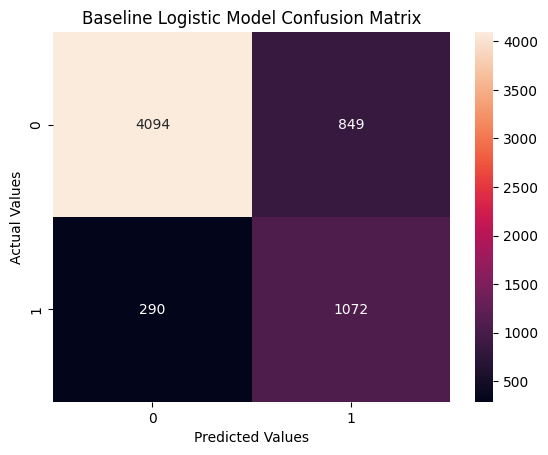

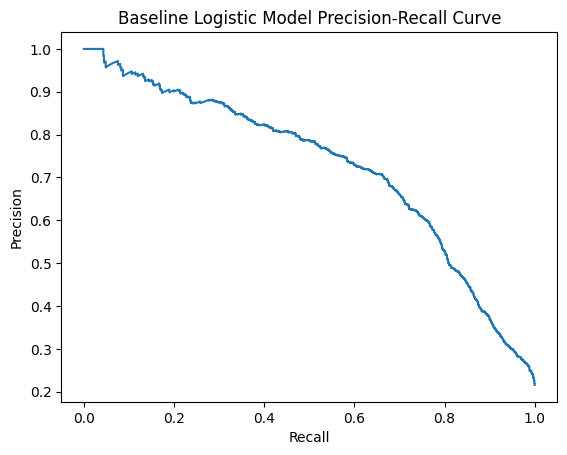

In [28]:


evaluate_model("Baseline Logistic Model", baseline_model ,x_test, y_test)

XG boost Hyperparameter tuning

In [29]:
xg_model = Pipeline([
    ('prepocessor',preprocessor_xg),
    ('classifier',XGBClassifier(learning_rate=0.1,
        scale_pos_weight=scale_weigths,random_state=42))
])
xg_model.fit(x_train, y_train)

,steps,"[('prepocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_grid = {
    "classifier__n_estimators": randint(150, 600),
    "classifier__max_depth" : randint(3,9),
    "classifier__learning_rate" : uniform(0.01, 0.5),
    "classifier__subsample": uniform(0.6,0.4), #Rows sampling
    "classifier__colsample_bytree" :uniform(0.6,0.4), #column sampling
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma": uniform(0 , 5)
}
# lower gamma -> more splits -> complex tree -> higher overfitting risk
# higher gamma -> less splits ->  simpler tree -> low overfitting

In [31]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)

random_search.fit(x_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


,estimator,"Pipeline(step...te=42, ...))])"
,param_distributions,"{'classifier__colsample_bytree': <scipy.stats....001FF7E040C70>, 'classifier__gamma': <scipy.stats....001FF7E040BE0>, 'classifier__learning_rate': <scipy.stats....001FF7E041780>, 'classifier__max_depth': <scipy.stats....001FF7E0407C0>, ...}"
,n_iter,150
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [32]:
print(f"score after performing hyper parameter tuning {random_search.best_score_:.2f}")

score after performing hyper parameter tuning 0.90


Comparing both models

LogisticRegression Metrics:
Accuracy : 0.82
Precision : 0.56
Recall : 0.79
F1 : 0.65

LogisticRegression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



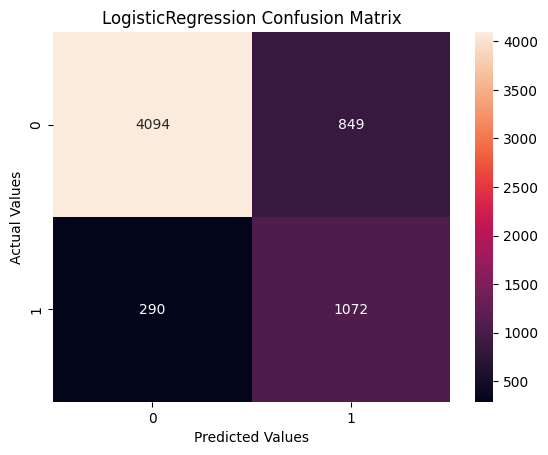

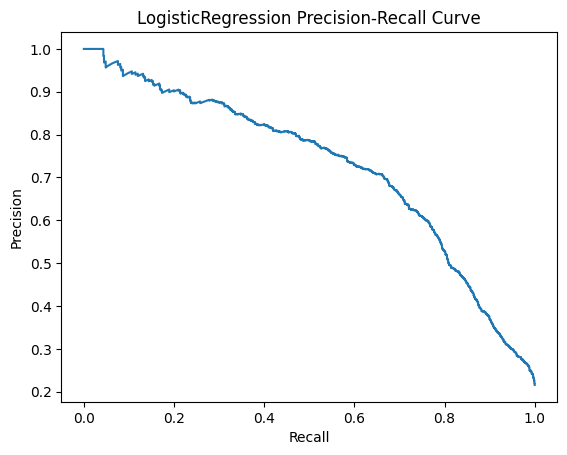

In [33]:
evaluate_model("LogisticRegression",baseline_model,x_test,y_test)

xg_model Metrics:
Accuracy : 0.92
Precision : 0.84
Recall : 0.80
F1 : 0.82

xg_model Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      4943
           1       0.84      0.80      0.82      1362

    accuracy                           0.92      6305
   macro avg       0.89      0.88      0.89      6305
weighted avg       0.92      0.92      0.92      6305



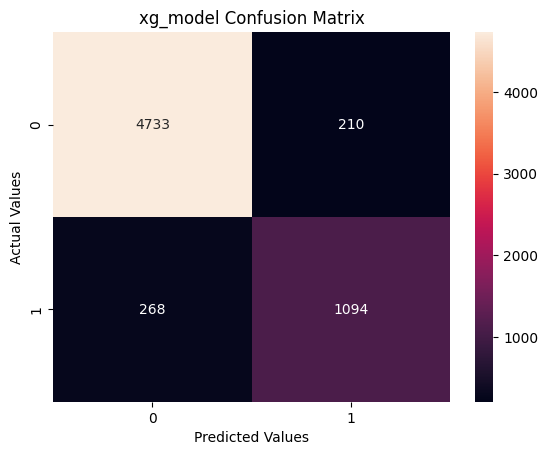

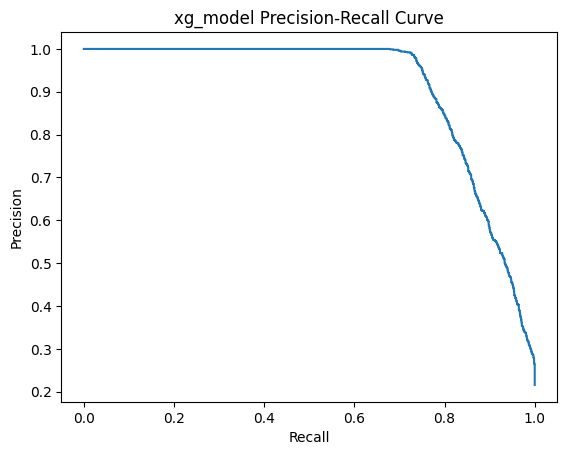

In [34]:
evaluate_model("xg_model",random_search,x_test,y_test)

Computing best threshold

XGBoost Metrics:
Used Threshold : 0.69
Accuracy : 0.94
Precision : 0.95
Recall : 0.74
F1 : 0.83

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4943
           1       0.95      0.74      0.83      1362

    accuracy                           0.94      6305
   macro avg       0.94      0.86      0.90      6305
weighted avg       0.94      0.94      0.93      6305



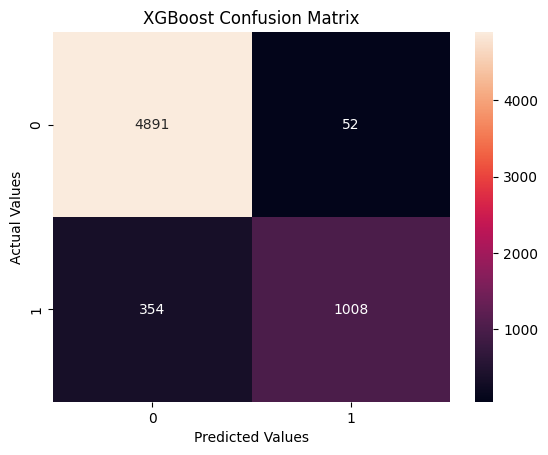

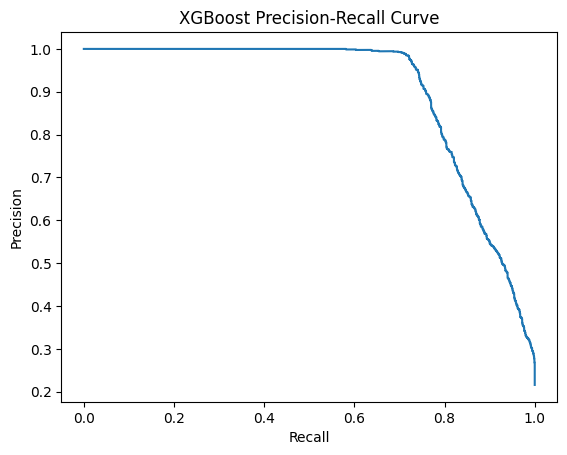

In [35]:
prob = xg_model.predict_proba(x_test)[:,1]

precisions , recalls , thresholds =precision_recall_curve(y_test,prob)

f1 = 2*(precisions*recalls)/(precisions+recalls+1e-9)

best = np.argmax(f1[:-1])

best_threshold = thresholds[best]

evaluate_model("XGBoost", xg_model, x_test, y_test, best_threshold)

Probability Calibration

In [36]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model,
    method='sigmoid',
    cv = 5
)

calibrated_model.fit(x_train,y_train)

,estimator,"Pipeline(step...te=42, ...))])"
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [37]:
uncalibrated = xg_model.predict_proba(x_test)[:,-1]
calibrated = calibrated_model.predict_proba(x_test)[:,-1]

In [38]:
actual_uncal , predicted_uncal = calibration_curve(y_test,uncalibrated,n_bins=10)
actual_cal , predicted_cal = calibration_curve(y_test,calibrated,n_bins=10)

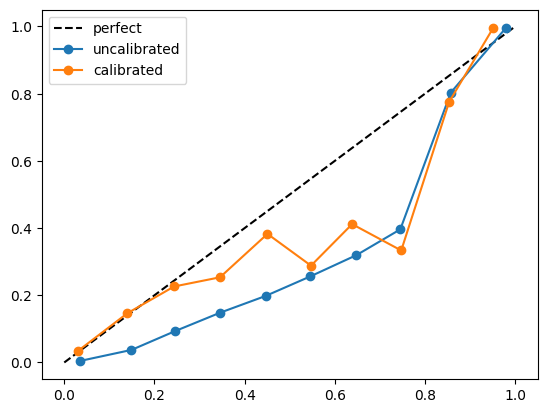

In [39]:
plt.plot([0,1],[0,1],'k--',label='perfect')

plt.plot(
    predicted_uncal,
    actual_uncal,
    'o-',
    label = 'uncalibrated'
)

plt.plot(
    predicted_cal,
    actual_cal,
    'o-',
    label = 'calibrated'
)

plt.legend()

shap predictions

In [40]:
import shap #type: ignore

xgb_classifier = xg_model.named_steps['classifier']

c:\Users\ypari\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [41]:
x_test_transform = xg_model.named_steps['prepocessor'].transform(x_test)

In [42]:
features_for_shap = xg_model.named_steps['prepocessor'].get_feature_names_out()

In [43]:
x_test_df = pd.DataFrame(x_test_transform,columns=features_for_shap)

In [44]:
explainer = shap.TreeExplainer(xgb_classifier)

In [45]:
shap_values = explainer.shap_values(x_test_df)

Global Explaination

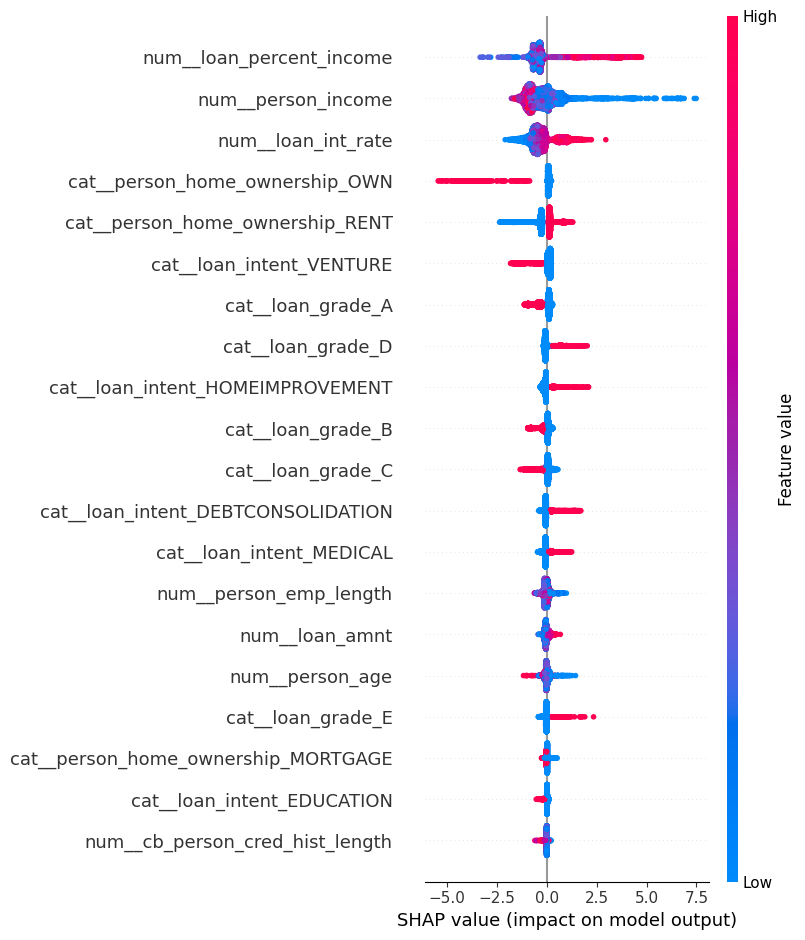

In [46]:
shap.summary_plot(shap_values,x_test_df)

Local Explaination

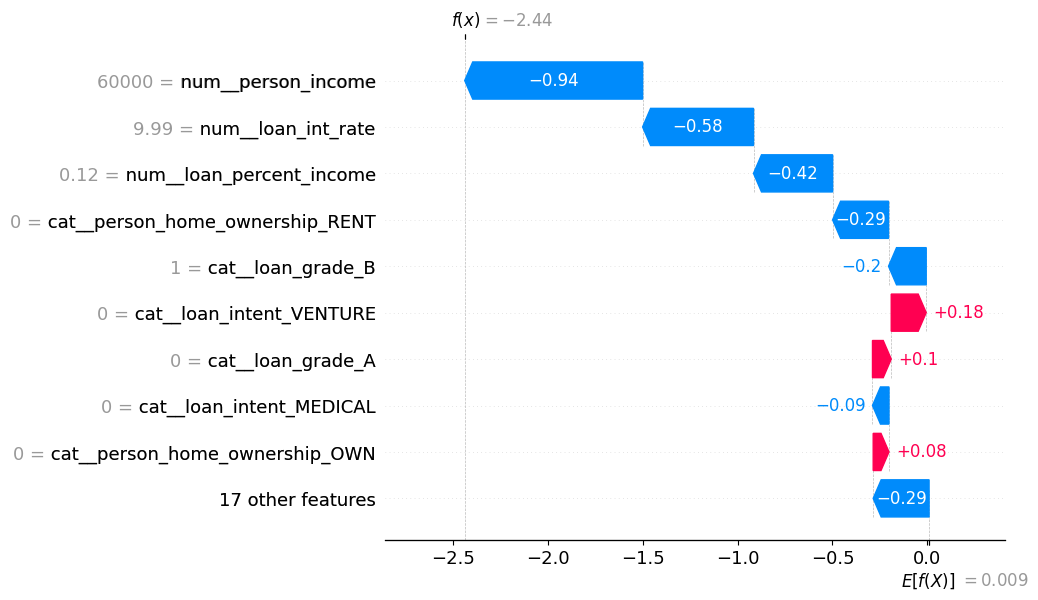

In [48]:
row_index = 5

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[row_index],
        base_values = explainer.expected_value,
        data =x_test_df.iloc[row_index],
        feature_names=features_for_shap
    )
)

Analysing false neg and false pos

In [49]:
y_pred = random_search.predict(x_test)

In [50]:
#Create a dataframe to easily compare the actual and predicted values
result_df = x_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [51]:
#Identify False Positive : Model Predicted 1, but the actual was 0
false_positive = result_df[(result_df['actual']== 0) & (result_df['predicted']== 1)]

#Identify False Negative : Model Predicted 0, but the actual was 1
false_negative = result_df[(result_df['actual']== 1) & (result_df['predicted']== 0)]

In [52]:
print(f"False Positive : {len(false_positive)}")
print(f"False Negative : {len(false_negative)}")
     

False Positive : 210
False Negative : 268


Saving the model

In [54]:
import joblib 
joblib.dump(calibrated_model,"credit_risk_nodel.pkl")

['credit_risk_nodel.pkl']

In [55]:
joblib.dump(best_threshold, "best_threshold.pkl")

['best_threshold.pkl']